In [1]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt
from parameter_oc import ParameterOC as poc
from parameter_oc import *
from helpful_functions import *
%load_ext autoreload
%autoreload 2

In [2]:
Nc_subspace_dim = 2          # cavity dim: levels 0...Nc-1 only for unitary target via projection
Nq_subspace_dim = 2          # qubit dim: levels 0...Nq-1 only for unitary target via projection
Nc_big = 10     # total cavity dim: includes higher levels
Nq_big = 2      # total qubit dim: includes higher levels

a_c = qt.tensor(qt.destroy(Nc_big), qt.qeye(Nq_big))   # cavity annihilation operator
a_q = qt.tensor(qt.qeye(Nc_big), qt.destroy(Nq_big))   # qubit annihilation operator
n_c = a_c.dag() * a_c                                 # cavity number operator
n_q = a_q.dag() * a_q                                 # qubit number operator

U_cross_target = (-1j * np.pi * (n_c * n_q)).expm() # this is the parity check gate
# U_kerr_target = (-1j * 0.1 * (n_c * n_c)).expm() # this is self kerr on cavity
# vaccum_ket = qt.tensor(qt.fock(Nc_big, 0), qt.fock(Nq_big, 0))
# final_ket = qt.tensor((qt.fock(Nc_big,0) + qt.fock(Nc_big, 5) + qt.fock(Nc_big, 10)).unit(), qt.fock(Nq_big, 0))
# partial_U_target_for_projection = final_ket * vaccum_ket.dag()  # |3,0><0,0| state transfer
# projector = projector_onto_states([vaccum_ket]) # only care about vaccum state input

gauge_ops = [n_c, n_q] # gauge ops
# gauge_ops = []
projector = projector_onto_states([qt.tensor(qt.fock(Nc_big, n_c_i), qt.fock(Nq_big, n_q_i)) for n_c_i in range(Nc_subspace_dim) for n_q_i in range(Nq_subspace_dim)])

In [21]:
num_apply = 6
unitary_strings = ["bs"] # ["r", "bs"] means rotation then beam-splitter, per j; ["bs", "r"] means beam-splitter then rotation, per j

opt = poc(
    unitary_strings=unitary_strings,
    target_unitary=U_cross_target,
    n_c=Nc_big,
    n_q=Nq_big,
    cost_type="projected",
    projector=projector,
    gauge_ops=gauge_ops,
)

n_rot = num_apply * len(unitary_strings)  # total number of rotation/phase params = n_base * num_apply
rotation0 = 1*np.random.uniform(0.0, np.pi/2, size=n_rot)  # random initial rotations
phase0 = 1*np.random.uniform(0.0, 2*np.pi, size=n_rot)     # random initial phases
theta0 = 1*np.random.uniform(0.0, 2*np.pi, size=len(gauge_ops))       # random initial gauge angles

# # rotation then beam-splitter, per j:
# rotation0 = np.array([
#     1.2874, 1.5560,   # r1, g1
#     1.1748, 0.7283,   # r2, g2
#     1.3744, 0.8322,   # r3, g3
#     1.4900, 0.7594,   # r4, g4
#     1.2629, 0.6553,   # r5, g5
#     1.2475, 0.6211,   # r6, g6
#     1.2549, 0.5879,   # r7, g7
#     1.1702, 0.5554,   # r8, g8
#     1.5708, 0.5236,   # r9, g9
#     1.5708, 0.4967,   # r10,g10
# ], dtype=float)

# # phases: 0 unless the original table entry was negative -> add π
# phase0 = np.array([
#     0.0,    0.0,      # +r1, +g1
#     np.pi,  0.0,      # -r2, +g2
#     np.pi,  np.pi,    # -r3, -g3
#     0.0,    0.0,      # +r4, +g4
#     0.0,    0.0,      # +r5, +g5
#     np.pi,  np.pi,    # -r6, -g6
#     np.pi,  np.pi,    # -r7, -g7
#     np.pi,  0.0,      # -r8, +g8
#     0.0,    0.0,      # +r9, +g9
#     0.0,    0.0,      # +r10,+g10
# ], dtype=float)

# pulses0, theta0 = load_pulses_theta("results/run1.npz")
options = {
        # <-- KEY ONE: make projected-gradient tolerance smaller => later termination
        "gtol": 1e-8,        # default is ~1e-5; try 1e-8, 1e-10, 1e-12

        # if you're stopping due to tiny objective improvements, tighten this too:
        "ftol": 1e-9,        # default ~2e-9; smaller => requires more improvement to stop

        # optional: allow more line-search steps per iteration
        "maxls": 500,
    }

out = opt.optimize(
    num_apply=num_apply,
    rotation0=rotation0,
    rotation_bounds=(0.0, np.pi), # bounds for rotation angles
    phase0=phase0,
    theta0=theta0,
    maxiter=200,
    n_starts=40,
    scipy_options=options,
    optimize_phases=True,
) # initial fidelity is small need to fix something to start with ideal case
F_final = opt.fidelity(out["rotation_opt"], out["phase_opt"], num_apply=num_apply, optimize_phases = True, theta=out["theta_opt"])
print(F_final)

Fidelity: 0.037455899478951116
Fidelity: 0.0913522539466978
Fidelity: 0.09054973848501016
Fidelity: 0.041983208022184464
Fidelity: 0.10836321641408109
Fidelity: 0.12972503629243065
Fidelity: 0.046203894846314986
Fidelity: 0.16882942753594565
Fidelity: 0.17942323570389154
Fidelity: 0.19521031627374935
Fidelity: 0.2229109170698636
Fidelity: 0.2476220563164635
Fidelity: 0.07679801733780542
Fidelity: 0.26349923179153717
Fidelity: 0.22361561314171072
Fidelity: 0.28170710222330086
Fidelity: 0.3075202077783393
Fidelity: 0.26920107064961923
Fidelity: 0.3267010876845116
Fidelity: 0.34236317096746394
Fidelity: 0.3774870507592068
Fidelity: 0.4046105054882259
Fidelity: 0.4304991734696885
Fidelity: 0.46213021030121043
Fidelity: 0.4278220073547461
Fidelity: 0.4819396970529299
Fidelity: 0.5135533982078682
Fidelity: 0.540357889398478
Fidelity: 0.5738248820162657
Fidelity: 0.6121206760176239
Fidelity: 0.6302213761138372
Fidelity: 0.6407268491118217
Fidelity: 0.644420941602935
Fidelity: 0.64665239728162

In [ ]:
opt.save_results("ParameterOc_results/parity_4cavitylevels.npz", out)

NameError: name 'opt' is not defined

In [24]:
filename = "ParameterOc_results/parity_4cavitylevels.npz" # test test
q = load_qobjs(filename)
rotation0, phase0, theta0 = load_rotation_phase_theta(filename)
parameters_dict = load_parameters_dict(filename)

Ut = q["U_target"]
P  = q["projector"]
gauge_ops = q["gauge_ops"]
a_c = q["a_c"]
a_q = q["a_q"]
print(P.tr())
# print(a_c)

phase0 = phase0
# phase0 = np.round(phase0, decimals=2) # round to fix numerical precision issues for plotting
# phase0 = phase0 + np.random.uniform(-1, 1, size=phase0.shape) # add small random noise to phases to break any numerical precision issues for plotting
U_final = propagate(parameters_dict["unitary_strings"], rotation0, phase0, parameters_dict["num_apply"], a_c, a_q, optimize_phases=parameters_dict["optimize_phases"])
G = gauge_unitary(gauge_ops, theta0)
g_unitary = G * U_final

print(rotation0)
print(phase0)

G_full = G.full()
g_unitary_full = g_unitary.full()

fidelity = unitary_projected_fidelity(Ut, g_unitary, P)
print("Fidelity check:", fidelity)

8.0
[1.74339552 2.19284214 3.14159265 0.90978651 2.91430645 1.45662988]
[1.18269223 4.87797472 3.23003019 4.92933003 0.78124016 2.73183111]
Fidelity check: 0.9996550554818028


# Test parity experiment

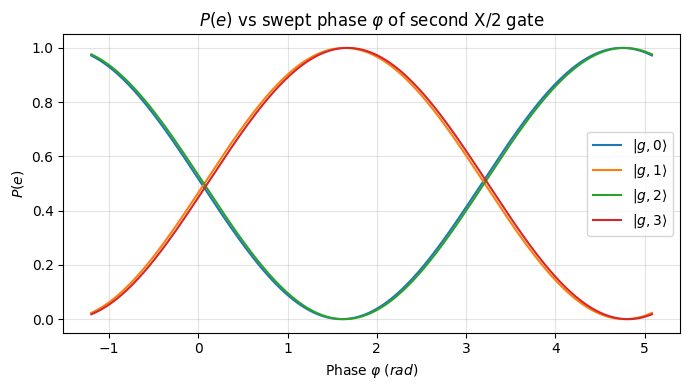

In [25]:
# Phased-X/2 Ramsey experiment
# Protocol: |g, n_c>  ->  X/2  ->  U_final  ->  R(phi)/2  ->  measure P(e)
#
# R(phi)/2 = exp(-i*pi/4*(cos(phi)*sigma_x + sin(phi)*sigma_y))  phased pi/2 gate

phases = np.linspace(0-1.2, 2*np.pi - 1.2, 300)

sigma_x_q = qt.tensor(qt.qeye(Nc_big), qt.sigmax())
sigma_y_q = qt.tensor(qt.qeye(Nc_big), qt.sigmay())

X2_gate = (-1j * np.pi/4 * sigma_x_q).expm()   # pi/2 rotation about x

init_states = {
    r'$|g,0\rangle$': qt.tensor(qt.fock(Nc_big, 0), qt.fock(Nq_big, 0)),
    r'$|g,1\rangle$': qt.tensor(qt.fock(Nc_big, 1), qt.fock(Nq_big, 0)),
    r'$|g,2\rangle$': qt.tensor(qt.fock(Nc_big, 2), qt.fock(Nq_big, 0)),
    r'$|g,3\rangle$': qt.tensor(qt.fock(Nc_big, 3), qt.fock(Nq_big, 0)),
    # r'$|g,4\rangle$': qt.tensor(qt.fock(Nc_big, 4), qt.fock(Nq_big, 0)),
}

Pe_results = {}
for label, psi0 in init_states.items():
    psi_mid = U_final * X2_gate * psi0
    Pe = []
    for phi in phases:
        R_phi = (-1j * np.pi/4 * (np.cos(phi)*sigma_x_q + np.sin(phi)*sigma_y_q)).expm()
        Pe.append(qt.expect(n_q, R_phi * psi_mid))
    Pe_results[label] = np.real(np.array(Pe))

fig, ax = plt.subplots(figsize=(7, 4))
for (label, Pe), c in zip(Pe_results.items(), ['C0', 'C1', 'C2', 'C3']):
    ax.plot(phases, Pe, color=c, lw=1.5, label=label)
ax.set_xlabel(r'Phase $\varphi\;(rad)$')
ax.set_ylabel(r'$P(e)$')
ax.set_title(r'$P(e)$ vs swept phase $\varphi$ of second X/2 gate')
# ax.set_xlim([0, 2])
ax.set_ylim([-0.05, 1.05])
# ax.set_xticks([0, 0.5, 1.0, 1.5, 2.0])
ax.legend()
ax.grid(alpha=0.35)
plt.tight_layout()
plt.show()


# seems like also get experiment agreement if x gate -> - x gate and sideband phase -> -sideband phase

In [ ]:
# Save theoretical Ramsey curves
save_path = "ParameterOc_results/ramsey_theory_curves2.npz"
labels = list(Pe_results.keys())
pe_arrays = np.array([Pe_results[l] for l in labels])
np.savez(save_path, phases=phases, Pe=pe_arrays, labels=np.array(labels))
print(f"Saved to {save_path}")

Saved to ParameterOc_results/ramsey_theory_curves.npz


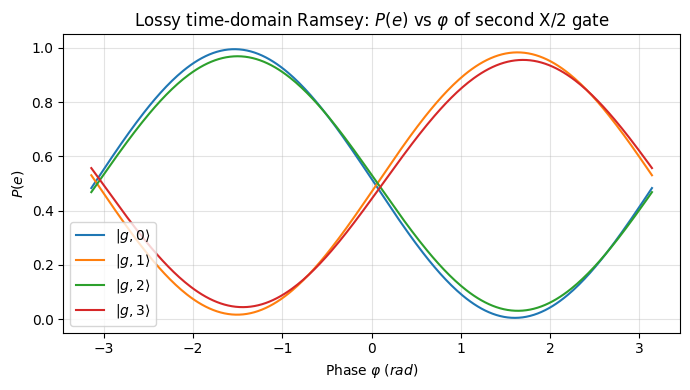

In [48]:
# Time-domain QuTiP simulation of the calibrated cavity-qubit exchange pulses
# Units: time is in us, so Hamiltonian rates are rad/us and T1 rates are 1/us.

import numpy as np
import matplotlib.pyplot as plt
import qutip as qt

from parameter_oc import load_qobjs, load_rotation_phase_theta, gauge_unitary
from helpful_functions import projector_onto_states, unitary_projected_fidelity

# Load the three optimized beam-splitter pulse areas and phases.
filename = "ParameterOc_results/parity_4cavitylevels.npz"
q = load_qobjs(filename)
rotation0, phase0, theta0 = load_rotation_phase_theta(filename)

a_c = q["a_c"]
a_q = q["a_q"]
Ut = q["U_target"]
P = q["projector"]
gauge_ops = q["gauge_ops"]
Nc_sim, Nq_sim = a_c.dims[0]

# Crossing times copied from pulse_calculations.ipynb.
# pulse_times_us = np.array([0.1111, 0.3568, 0.1111])

pulse_times_us = np.array([0.2752, 0.3521, 0.5146, 0.1324, 0.4757, 0.2261])

# The optimized pulse area theta is matched by choosing g_rate * time = theta.
theta_pulses = np.asarray(rotation0[:len(pulse_times_us)], dtype=float)
phase_pulses = np.asarray(phase0[:len(pulse_times_us)], dtype=float)
g_rates = theta_pulses / pulse_times_us

pulses = []
for k, (theta, phase, time_us, g_rate) in enumerate(
    zip(theta_pulses, phase_pulses, pulse_times_us, g_rates),
    start=1,
):
    pulses.append(
        {
            "label": f"BS{k}",
            "theta": theta,
            "phase": phase,
            "time_us": time_us,
            "g_rate": g_rate,
        }
    )

T1_cavity_us = 80.0
T1_qubit_us = 150.0

n_c_op = a_c.dag() * a_c
n_q_op = a_q.dag() * a_q

c_ops = [np.sqrt(1 / T1_cavity_us) * a_c, np.sqrt(1 / T1_qubit_us) * a_q]


def bs_hamiltonian(g_rate, phase):
    """Beam-splitter Hamiltonian for one calibrated pulse."""
    return g_rate * (
        a_c.dag() * a_q * np.exp(1j * phase)
        + a_c * a_q.dag() * np.exp(-1j * phase)
    )


def evolve_with_decay(rho0, pulses, points_per_us=400):
    """Run the pulse sequence with cavity and qubit T1 decay."""
    rho = rho0

    for pulse in pulses:
        H = bs_hamiltonian(pulse["g_rate"], pulse["phase"])
        n_points = max(30, int(np.ceil(points_per_us * pulse["time_us"])))
        tlist = np.linspace(0.0, pulse["time_us"], n_points + 1)

        result = qt.mesolve(
            H,
            rho,
            tlist,
            c_ops=c_ops,
            options={"store_states": True, "nsteps": 10000},
        )
        rho = result.states[-1] # get final state
    return rho

def ket_probability(ket, rho):
    value = ket.dag() * rho * ket
    if hasattr(value, "full"):
        value = value.full()[0, 0]
    return float(np.real(value))

# ── Phased-X/2 Ramsey experiment with lossy BS pulses ──────────────────────────
# Protocol: |g, n_c>  ->  X/2  ->  [BS pulses with T1 decay]  ->  R(phi)/2  ->  measure P(e)
# R(phi)/2 = exp(-i*pi/4*(cos(phi)*sigma_x + sin(phi)*sigma_y))
#
# X/2 puts the qubit on the equator; the phase fringes then reveal the
# photon-number-dependent phase accumulated by the exchange sequence.

phases = np.linspace(-np.pi, 1 * np.pi, 300)
sigma_x_q = qt.tensor(qt.qeye(Nc_sim), qt.sigmax())
sigma_y_q = qt.tensor(qt.qeye(Nc_sim), qt.sigmay())
X2_gate = (-1j * np.pi / 4 * sigma_x_q).expm()

ramsey_states = {
    r"$|g,0\rangle$": qt.tensor(qt.fock(Nc_sim, 0), qt.fock(Nq_sim, 0)),
    r"$|g,1\rangle$": qt.tensor(qt.fock(Nc_sim, 1), qt.fock(Nq_sim, 0)),
    r"$|g,2\rangle$": qt.tensor(qt.fock(Nc_sim, 2), qt.fock(Nq_sim, 0)),
    r"$|g,3\rangle$": qt.tensor(qt.fock(Nc_sim, 3), qt.fock(Nq_sim, 0)),
}

# One mesolve call per initial state; phi sweep is pure matrix algebra.
Pe_results = {}
for label, psi0 in ramsey_states.items():
    psi_equator = X2_gate * psi0
    rho_mid = evolve_with_decay(psi_equator * psi_equator.dag(), pulses)
    Pe = []
    for phi in phases:
        R_phi = (-1j * np.pi / 4 * (np.cos(phi) * sigma_x_q + np.sin(phi) * sigma_y_q)).expm()
        Pe.append(qt.expect(n_q_op, R_phi * rho_mid * R_phi.dag()))
    Pe_results[label] = np.real(np.array(Pe))

fig, ax = plt.subplots(figsize=(7, 4))
for (label, Pe), color in zip(Pe_results.items(), ["C0", "C1", "C2", "C3"]):
    ax.plot(phases, Pe, color=color, lw=1.5, label=label)
ax.set_xlabel(r"Phase $\varphi\;(rad)$")
ax.set_ylabel(r"$P(e)$")
ax.set_title(r"Lossy time-domain Ramsey: $P(e)$ vs $\varphi$ of second X/2 gate")
ax.set_ylim([-0.05, 1.05])
ax.legend()
ax.grid(alpha=0.35)
plt.tight_layout()
plt.show()


In [19]:
print(Nq_sim)

2
